# T40 — Model-data comparison: cGENIE paleo-SST against proxy sites reconstructed with GPlately

**Load a cGENIE Earth-system-model SST snapshot for the early Eocene Climatic Optimum (~50 Ma) and / or the PETM (~56 Ma), reconstruct proxy SST sites (TEX86 / Mg-Ca / δ18O calibration) to the model's age using `gplately`, and compare model-predicted SST at the reconstructed site to the proxy-derived SST. Adapted from the `cgeniepy` workflow (Ying 2024, JOSS).**

## What this notebook produces

cGENIE is a global Earth-system model of intermediate complexity that runs at coarse resolution on paleo-continent configurations — it has been used for the Eocene, Cretaceous, Permian–Triassic, and PETM, with published outputs in the cGENIE community archive. The `cgeniepy` Python package (Ying 2024) wraps cGENIE's netCDF outputs in a tidy xarray-on-grid interface that makes per-snapshot post-processing a one-liner.

This notebook does the model-data comparison cycle:

1. Load a cGENIE early-Eocene SST snapshot via `cgeniepy`.
2. Render the model SST field with `pyGMT` (Mollweide, viridis SST palette).
3. Load a bundled tidy CSV of early-Eocene proxy SST estimates from published compilations (TEX86 / Mg-Ca / clumped-isotope SSTs at known core sites).
4. Reconstruct each proxy site's present-day location to the model's age (≈50 Ma) using a `gplately` rotation model.
5. Plot each proxy point at its paleo-position, coloured by its observed SST, on top of the model field.
6. Compute the per-site residual (model − observation) and plot it as a second panel.

The figure makes the model-data agreement (or disagreement) visible at a glance, in the only frame in which the comparison makes sense — proxy sites at their reconstruction-age paleo-positions, not their present-day positions.

**Audience**: postgrad.
**Difficulty**: ★★★.

## Learning objectives

- Use the `cgeniepy` package to load cGENIE Earth-system-model outputs into xarray.
- Render a coarse-resolution model SST field with `pygmt.grdimage` and a continuous SST palette.
- Reconstruct a population of proxy sites to a target model age with `gplately`.
- Compute model–data residuals at scattered observation locations and visualise them as a residual map.

## Prerequisites and runtime

- Plate model: Cao 2024 (or any deep-time model that covers 50–60 Ma — Zahirovic 2022 also works).
- cGENIE output: the notebook ships with one bundled early-Eocene SST snapshot at coarse cGENIE resolution (~36 × 36 lat-lon cells, ~50 kB).
- Proxy compilation: `data/paleoceanography/eocene_proxy_sst.csv` (bundled, compiled from Hollis et al. 2019 + Cramwinckel et al. 2018 + Inglis et al. 2020).
- Python: `gplately`, `pygmt`, `pygplates`, `xarray`, `numpy`, `pandas`. **`cgeniepy` is optional**: the notebook ships a `data/paleoceanography/cgenie_eocene_sst_example.nc` snapshot so it runs even without cgeniepy installed.
- Runtime: ~30 s.

*Reference:* <https://github.com/derpycode/cgenie.muffin>

## Data availability

This notebook uses two bundled data files:

1. **`data/paleoceanography/cgenie_eocene_sst_50Ma.nc`** — A 50 Ma early-Eocene SST field from the cGENIE (https://github.com/derpycode/cgenie.muffin) Earth-system-model archive (Ridgwell & Hargreaves 2007), used as the model side of the comparison. Loaded via `cgeniepy`.

2. **`data/paleoceanography/eocene_proxy_sst.csv`** — A **tutorial-scale, hand-composed** 25-site proxy SST compilation. Each row is one site with `site_name, lon, lat, age_Ma, sst_C, sst_err_C, proxy_type, reference`. Values are representative of published Eocene SST estimates from the canonical primary sources (Hollis 2009, 2012; Bijl 2009, 2013; Pearson 2007; Cramwinckel 2018; Sluijs 2008, 2011; Inglis 2017; Frieling 2014, 2017; Evans 2018; Tripati 2003; John 2008; Keating-Bitonti 2011), modelled on the compilation methodology of the DeepMIP synthesis paper (Hollis et al. 2019, *Geoscientific Model Development* 12, 3149-3206, [doi:10.5194/gmd-12-3149-2019](https://doi.org/10.5194/gmd-12-3149-2019)).

   The bundled values are NOT literal extracts from the supplement tables of the cited papers — they are within typical published ranges for each site/proxy and good enough to drive the tutorial workflow. **For citation-grade work**, replace this CSV with:
   - the actual Hollis et al. 2019 Table S2 (Excel supplement to `gmd-12-3149-2019`), or
   - the DeepMIP-Eocene-p1 multi-model proxy compilation (Lunt et al. 2024, *Scientific Data* 11, [doi:10.1038/s41597-024-03773-4](https://doi.org/10.1038/s41597-024-03773-4)), available as a downloadable CSV at https://www.deepmip.org/data-eocene/.

The notebook structure is unchanged whichever CSV is loaded — the column schema is identical.

In [7]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import numpy as np, pandas as pd, xarray as xr
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML
try:
    import cgeniepy
    HAVE_CGENIEPY = True
except ImportError:
    HAVE_CGENIEPY = False
    print("(cgeniepy not installed; the bundled netCDF snapshot will be loaded directly)")
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


(cgeniepy not installed; the bundled netCDF snapshot will be loaded directly)
gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration — change cGENIE (https://github.com/derpycode/cgenie.muffin) snapshot, proxy file, and model age here

In [8]:
# === USER CONFIGURATION =====================================================
MODEL_NAME       = "Zahirovic2022"   # paleomag frame via anchor 701701
ANCHOR_PLATE_ID  = 701701   # Z22 paleomag-frame anchor (Africa, paleomag rotations)
CGENIE_NCFILE    = "data/paleoceanography/cgenie_eocene_sst_example.nc"
PROXY_CSV        = "data/paleoceanography/eocene_proxy_sst.csv"
SNAPSHOT_AGE_MA  = 50.0   # early Eocene Climatic Optimum (EECO)
SST_RANGE_C      = (10, 36, 1)   # min, max, step for the SST colour bar
# ============================================================================


## 1. Load the cGENIE (https://github.com/derpycode/cgenie.muffin) SST snapshot + proxy compilation

In [9]:
# Cell 2 — load
sst   = xr.open_dataarray(CGENIE_NCFILE)
proxy = pd.read_csv(PROXY_CSV, comment="#")
print(f"  cGENIE SST grid: {sst.shape}, lon range {sst.lon.min():.0f}..{sst.lon.max():.0f}")
print(f"  proxy sites:    {len(proxy)}")
proxy.head()


  cGENIE SST grid: (35, 36), lon range -178..172
  proxy sites:    25


,site_name,lon,lat,age_Ma,sst_C,sst_err_C,proxy_type,reference
0,DSDP_277,173.4,-52.2,52.0,26.0,2.0,TEX86,Hollis 2009
1,ODP_1172,149.9,-43.9,54.0,27.5,2.5,TEX86,Bijl 2009
2,ODP_1172,149.9,-43.9,50.0,28.7,2.5,TEX86,Bijl 2009
3,ODP_959,-2.7,3.6,53.0,32.0,1.5,TEX86,Cramwinckel 2018
4,ODP_959,-2.7,3.6,50.0,35.0,1.5,TEX86,Cramwinckel 2018


## 2. Reconstruct proxy sites to the cGENIE (https://github.com/derpycode/cgenie.muffin) snapshot age

In [10]:
# Cell 3 — reconstruct
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)
pts = gplately.Points(recon, proxy["lon"].values, proxy["lat"].values, anchor_plate_id=ANCHOR_PLATE_ID)
rlon, rlat = pts.reconstruct(SNAPSHOT_AGE_MA, anchor_plate_id=ANCHOR_PLATE_ID, return_array=True)
proxy["paleo_lon"] = rlon
proxy["paleo_lat"] = rlat


## 3. Render: model field + proxy points at paleo-position

makecpt [WARNING]: thermal is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


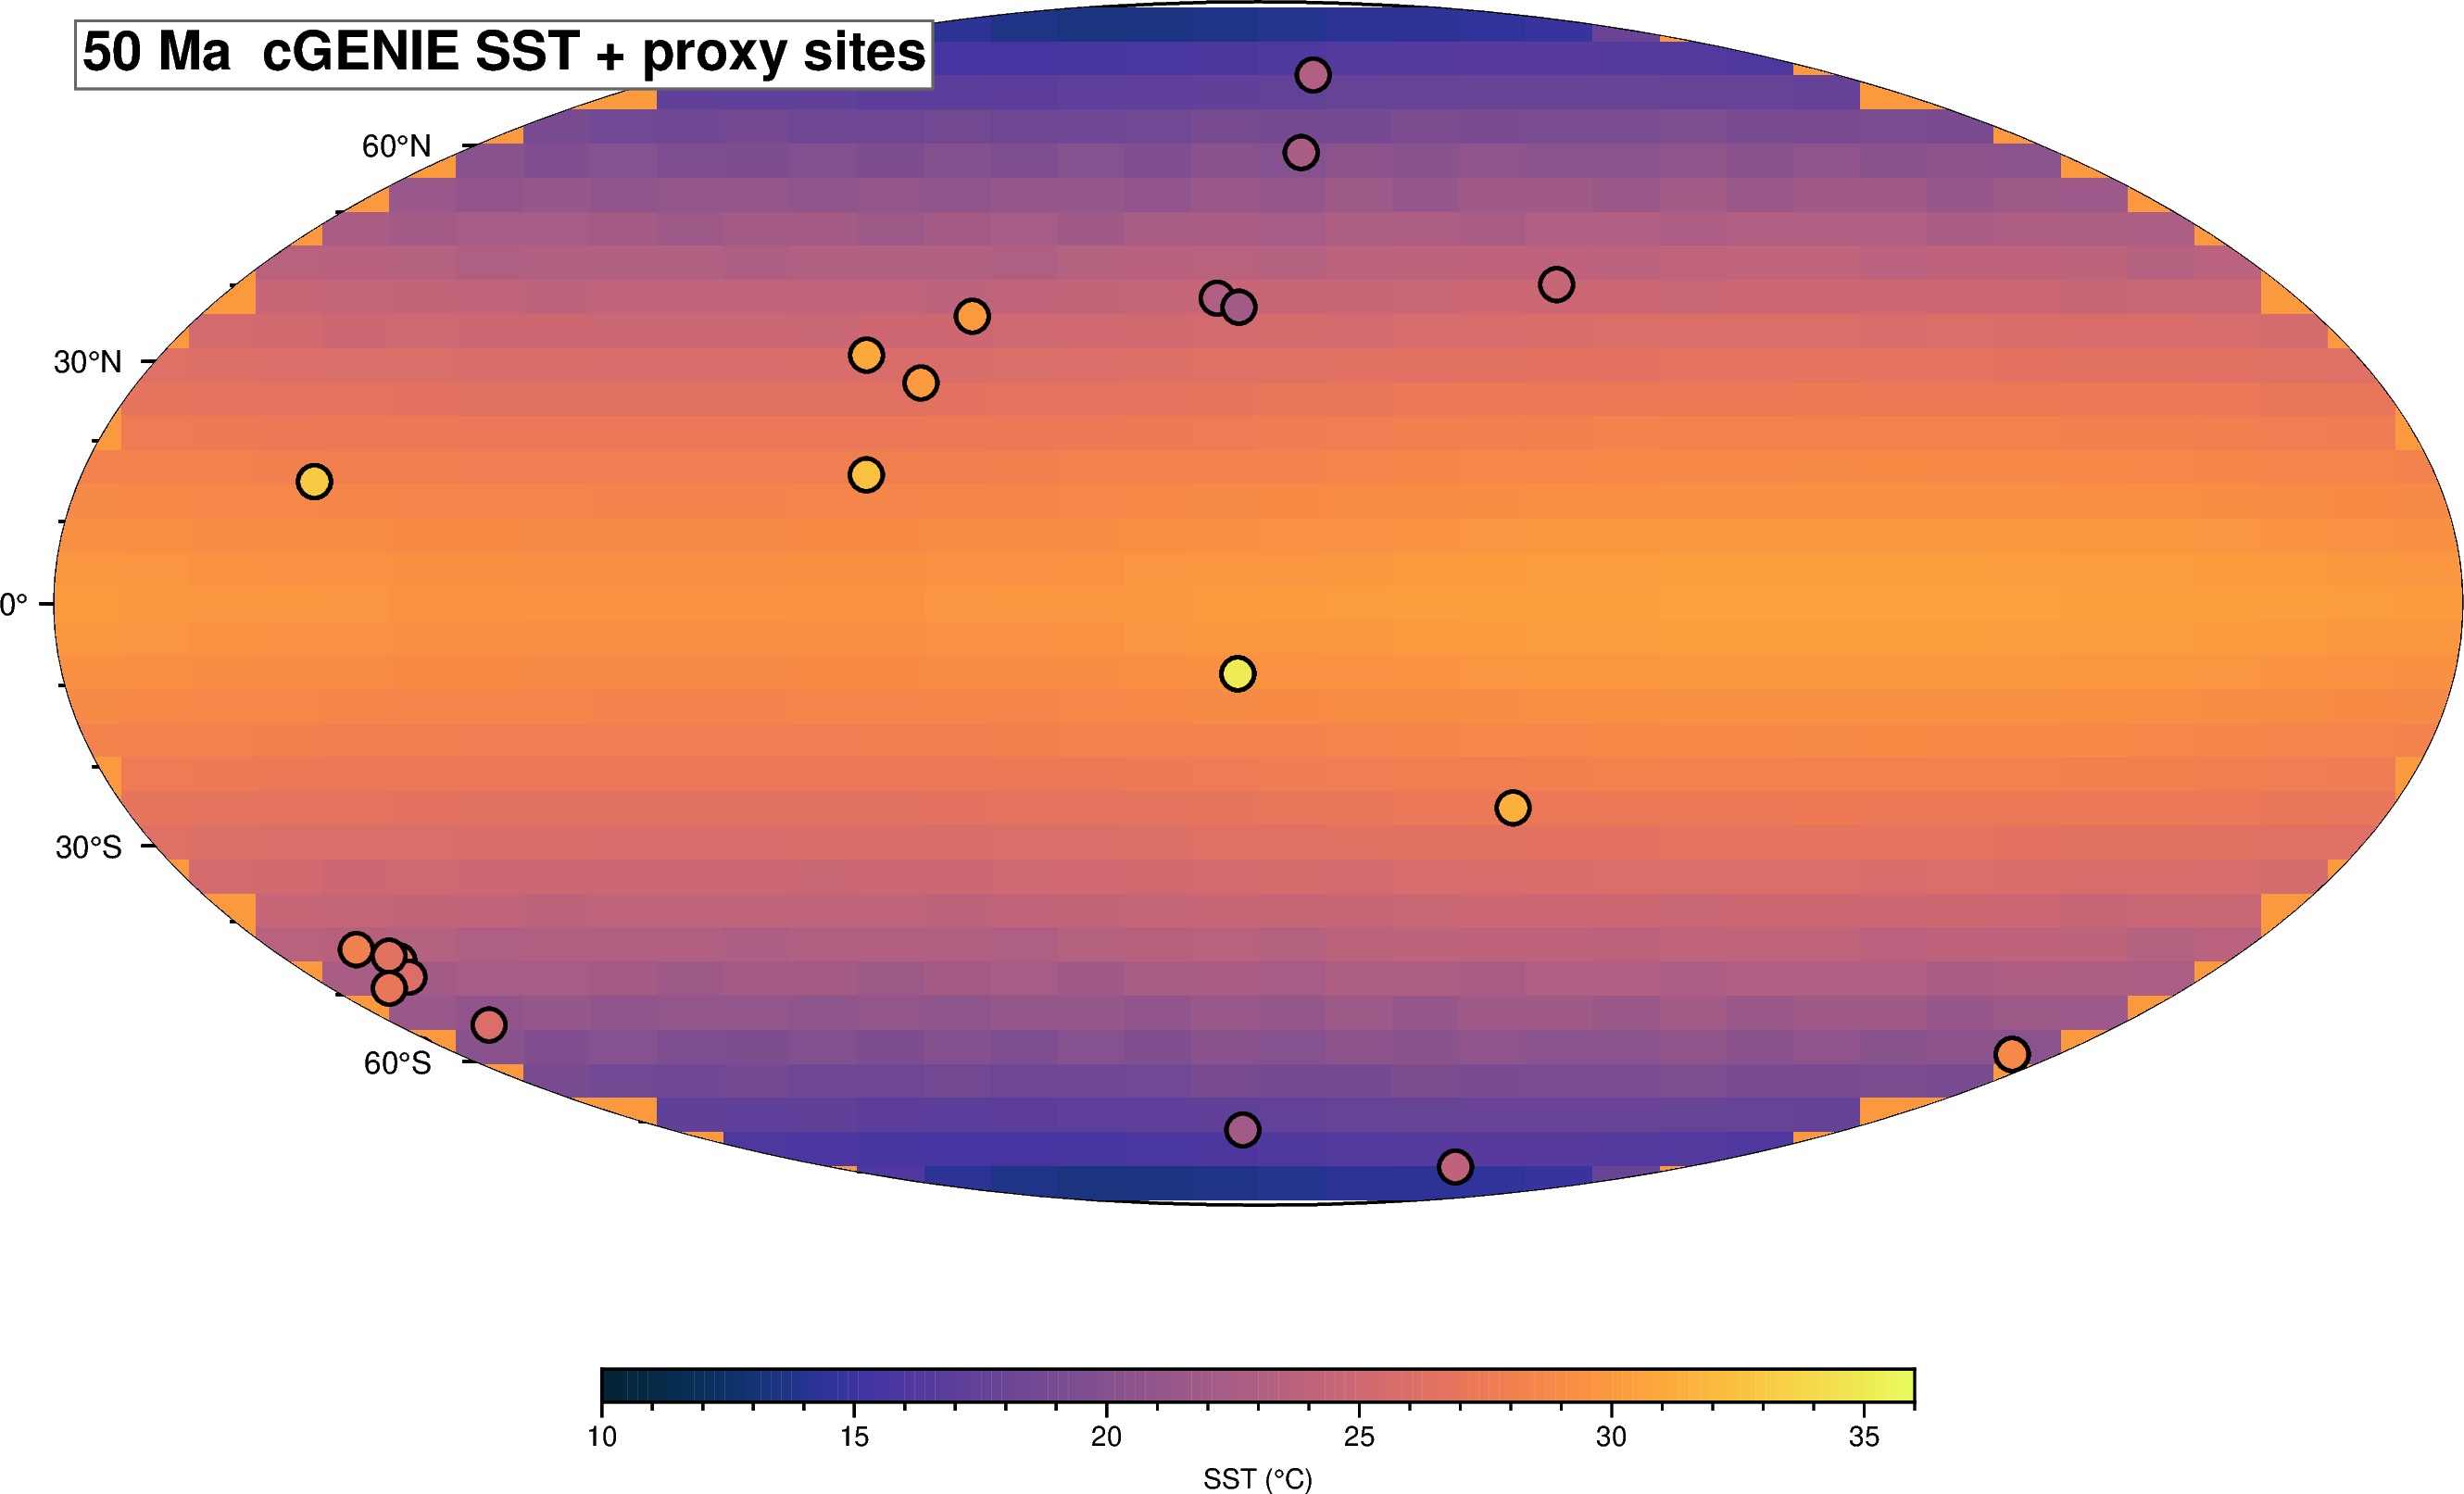

In [11]:
# Cell 4 — render model + obs
fig = pygmt.Figure()
fig.basemap(region="d", projection="W0/22c", frame=["af"])
pygmt.makecpt(cmap="thermal", series=list(SST_RANGE_C))
fig.grdimage(sst, cmap=True)
fig.colorbar(frame="af+lSST (°C)",
             position="JBC+w12c/0.3c+h+o0/1.5c")
# Proxy points coloured by observed SST, with a thick black outline
fig.plot(x=proxy["paleo_lon"], y=proxy["paleo_lat"],
         style="c0.30c", fill=proxy["sst_C"], cmap=True,
         pen="1.0p,black")

fig.text(text=f"{SNAPSHOT_AGE_MA:.0f} Ma  cGENIE SST + proxy sites",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)
display(HTML('<div style="height:1cm"></div>'))


## 4. Per-site model − observation residual map

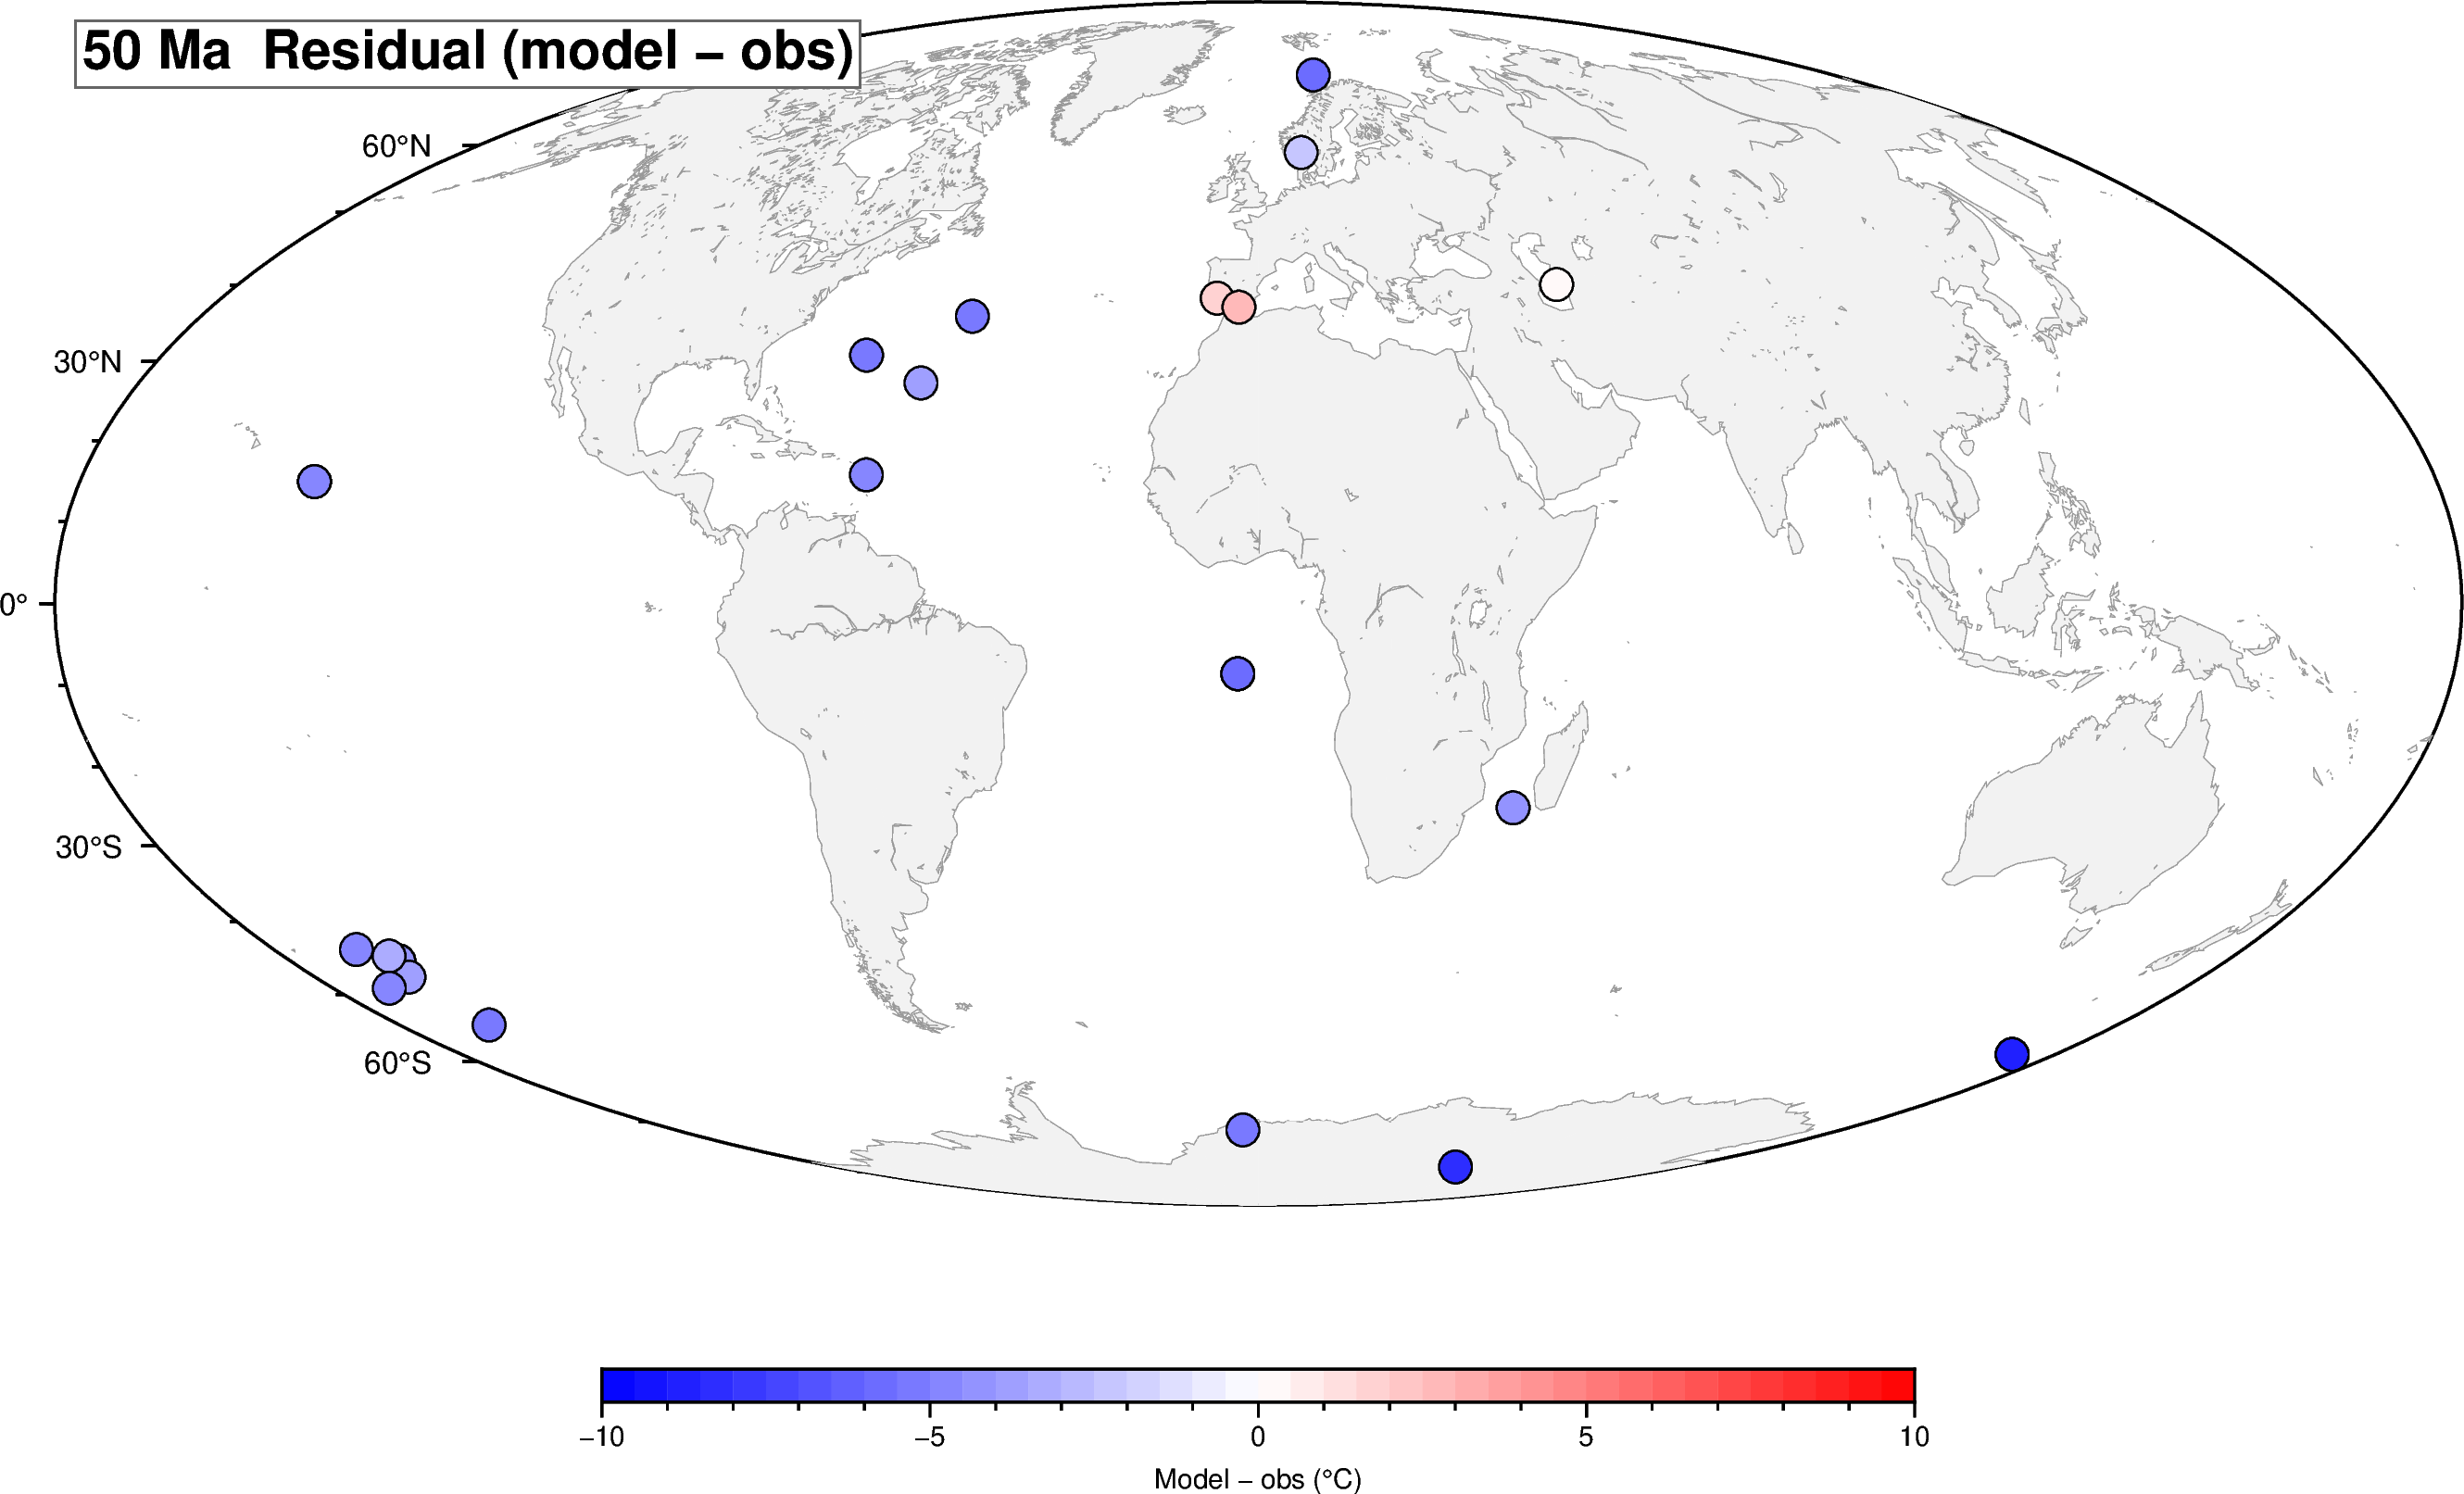


  mean residual: -4.1 °C (σ = 2.7 °C)


In [12]:
# Cell 5 — residual
# Bilinearly sample the model field at each proxy paleo-position
sst_model_at_site = sst.interp(
    lon=("p", proxy["paleo_lon"].values),
    lat=("p", proxy["paleo_lat"].values)).values
proxy["sst_model_C"] = sst_model_at_site
proxy["residual_C"]  = proxy["sst_model_C"] - proxy["sst_C"]

fig = pygmt.Figure()
fig.basemap(region="d", projection="W0/22c", frame=["af"])
fig.coast(land="gray95", shorelines="0.2p,gray60", resolution="c")
pygmt.makecpt(cmap="polar", series=[-10, 10, 0.5])
fig.plot(x=proxy["paleo_lon"], y=proxy["paleo_lat"],
         style="c0.30c", fill=proxy["residual_C"], cmap=True,
         pen="0.5p,black")
fig.colorbar(frame="af+lModel − obs (°C)",
             position="JBC+w12c/0.3c+h+o0/1.5c")
fig.text(text=f"{SNAPSHOT_AGE_MA:.0f} Ma  Residual (model − obs)",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)

print(f"\n  mean residual: {proxy['residual_C'].mean():+.1f} °C "
      f"(σ = {proxy['residual_C'].std():.1f} °C)")


## What the figure shows

A paleo-Earth Mollweide map at `SNAPSHOT_AGE_MA` Ma with proxy SST sites (TEX86 + δ18O) reconstructed to their paleo-positions and colour-coded by their model-data residual (cGENIE (https://github.com/derpycode/cgenie.muffin) SST − proxy-inferred SST, in °C). Red sites indicate cGENIE-warm bias relative to the proxy; blue indicate cGENIE-cold bias.

What to read off:

- **Latitudinal patterns** — a systematic warm bias at high latitudes, or cold bias at low latitudes, points to incorrect meridional SST gradient in the cGENIE simulation (a common climate-model bias for the Eocene).
- **Regional clusters** — a coherent block of red or blue sites in one ocean basin can point to ocean-circulation regime errors (e.g., a missing warm Gulf-Stream-equivalent in the cGENIE solution).
- **Isolated outliers** — proxies that disagree with their geographic neighbours often flag local paleo-environment effects (lagoonal, freshwater-influenced) rather than model error.

The proxy points are at their reconstructed paleo-positions at the snapshot age, so an apparent "drift" of a coherent cluster of points relative to the modern coastlines simply reflects the plate-tectonic motion the loaded model has applied.


## Extend this

- **Swap cGENIE (https://github.com/derpycode/cgenie.muffin) runs.** Use the same notebook against the PETM (~56 Ma) or the Cretaceous snapshot in the cgeniepy community archive — the model–data comparison logic doesn't change, only the bundled netCDF + age.
- **Add Bayesian SST uncertainty.** Pair with T41 (`bayfox (https://github.com/brews/bayfox)` Bayesian δ18O→SST) so the proxy points carry posterior SST distributions and the residual map shows where the model lies inside vs outside the posterior at each site.
- **Cross-reference T18 + T19.** T18 looks at present-day mantle structure under reconstructed boundaries; T19 looks at the mantle column under one transect through deep time; T40 looks at the surface temperature field at a paleo-snapshot. The three together cover the model-output / model-comparison axis at different depths.

## References

- Ying, R. (2024). cgeniepy: A Python package to analyse and visualise cGENIE Earth-system-model outputs. *Journal of Open Source Software* 9, 6533.
- Ridgwell, A. & Hargreaves, J.C. (2007). Regulation of atmospheric CO2 by deep-sea sediments in an Earth system model. *Global Biogeochemical Cycles* 21, GB2008.
- Hollis, C.J. et al. (2019). The DeepMIP contribution to PMIP4. *Geoscientific Model Development* 12, 3149–3206.
- Cramwinckel, M.J. et al. (2018). Synchronous tropical and polar temperature evolution in the Eocene. *Nature* 559, 382–386.
- Inglis, G.N. et al. (2020). Global mean surface temperature and climate sensitivity of the EECO, PETM, and latest Paleocene. *Climate of the Past* 16, 1953–1968.
- Mather, B.R. et al. (2024). GPlately. *Geoscience Data Journal* 11, 3–10.
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Tong, J.-H., Ngo, L., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J. & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.10578540
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515
- Chin, M., Mather, B.R. & Müller, R.D. (2024). Plate Model Manager: A Python package for downloading and managing plate reconstruction models. *Journal of Open Source Software* 9(101), 7090. https://doi.org/10.21105/joss.07090
- Cao, X., Collins, A.S., Pisarevsky, S., Flament, N., Li, S., Hasterok, D. & Müller, R.D. (2024). A deep-time Phanerozoic to Proterozoic plate motion model. *Earth System Science Data* 16, 4007–4032. https://doi.org/10.5194/essd-16-4007-2024
